In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F
import random
from matplotlib.patches import Ellipse
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from src import K_means
from src import GMM
from src import DBSCAN
from src import PCA
from src import VAE

In [32]:
df = pd.read_csv("data/clustering.csv")
df = df.iloc[:, 1:] #saco los indices
print("Shape de X_images:",df.shape)
# revisar nans, dataset bastante limpio
print("Cantidad de nan en X_images:", np.isnan(df).sum())
for col in df.columns:
    df[col] = (df[col] - df[col].mean()) / df[col].std()
X = df.values 
                

Shape de X_images: (4999, 2)
Cantidad de nan en X_images: A    0
B    0
dtype: int64


# Alogoritmos de clustering


No hay mejora significativa en k=16. Se detiene.


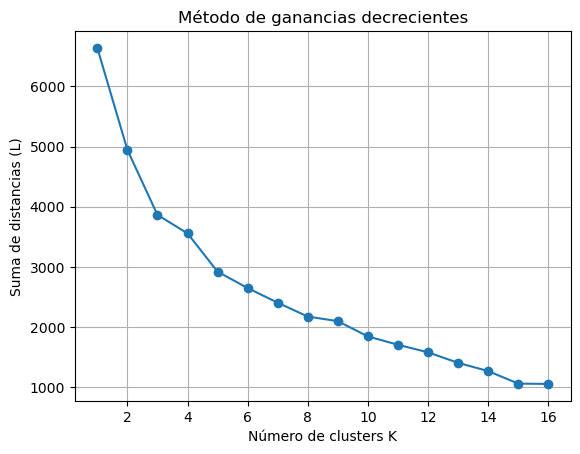

Mejor número de clusters: 15
Pérdida mínima: 1060.6852249492078


In [3]:
tol = 10  # tolerancia mínima para mejora
best_loss = float('inf')
best_k = None
loss_k = []

Ks = range(1, 100)
for k in Ks:
    model = K_means(n_clusters=k)
    _, _, l = model.fit(X)
    loss_k.append(l)

    # Verificar mejora
    if best_loss - l > tol:
        best_loss = l
        best_k = k
    else:
        print(f"No hay mejora significativa en k={k}. Se detiene.")
        break  # Parar si no hay mejora significativa

# Visualización
plt.plot(Ks[:len(loss_k)], loss_k, marker='o')
plt.title("Método de ganancias decrecientes")
plt.xlabel("Número de clusters K")
plt.ylabel("Suma de distancias (L)")
plt.grid(True)
plt.show()

print(f"Mejor número de clusters: {best_k}")
print(f"Pérdida mínima: {best_loss}")

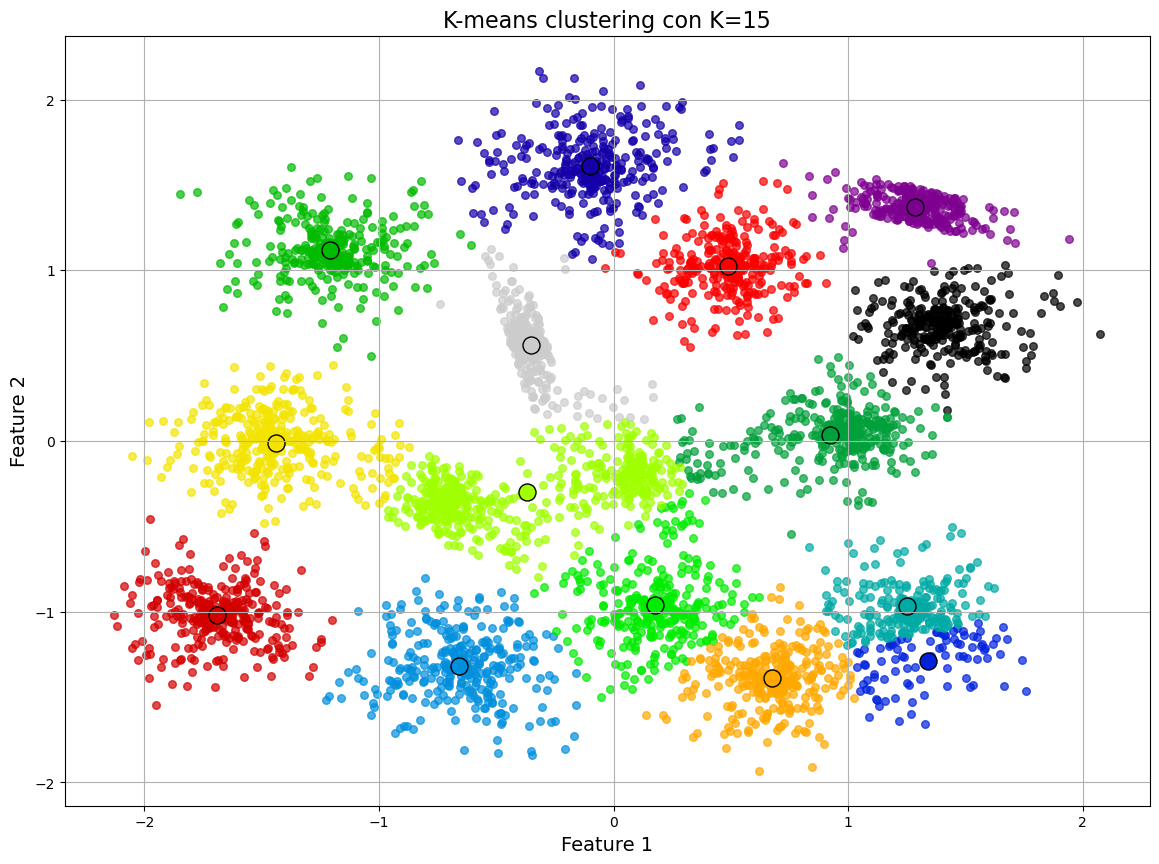

In [ ]:

k_opt = best_k
model = K_means(n_clusters=k_opt)
centroids, labels, l = model.fit(X)
cmap = plt.cm.get_cmap("nipy_spectral", k_opt) # el que mejor se ve

plt.figure(figsize=(14, 10)) 

for i in range(k_opt):
    cluster_points = X[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                color=cmap(i), label=f'Cluster {i+1}', s=30, alpha=0.7)
    plt.scatter(centroids[i, 0], centroids[i, 1],
                color=cmap(i), edgecolor='black', s=150, marker='o')

plt.title(f"K-means clustering con K={k_opt}", fontsize=16)
plt.xlabel("Feature 1", fontsize=14)
plt.ylabel("Feature 2", fontsize=14)
plt.grid(True)
plt.show()

Converged (parameters stable) at iteration 5
Converged (parameters stable) at iteration 68
Converged (parameters stable) at iteration 65
Converged (parameters stable) at iteration 84
Converged (parameters stable) at iteration 147
Converged (parameters stable) at iteration 73
Converged (parameters stable) at iteration 102
Converged (parameters stable) at iteration 86
Converged (parameters stable) at iteration 192
Converged (parameters stable) at iteration 204
Converged (parameters stable) at iteration 155
Converged (parameters stable) at iteration 169
Converged (parameters stable) at iteration 151
Converged (parameters stable) at iteration 196
Converged (parameters stable) at iteration 222
Para k=15, la pérdida es 1287.2893883708646.
Converged (parameters stable) at iteration 246
Converged (parameters stable) at iteration 286
Converged (parameters stable) at iteration 190
Converged (parameters stable) at iteration 314
Converged (parameters stable) at iteration 345
Converged (parameters 

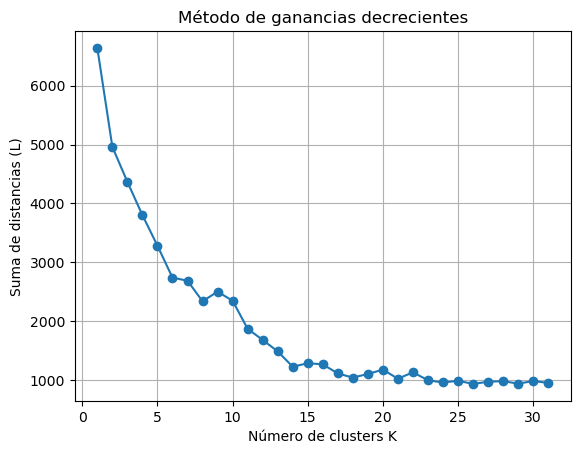

Mejor número de clusters: 26
Pérdida mínima: 935.8554734133081


In [33]:
tol = 10  # tolerancia mínima para mejora
best_loss = float('inf')
best_k = None
loss_k = []
wait = 0
patience = 5  # la implemento para evitar que se quede iterando sin mejora pero que no corte el proceso antes de encontrar un valor que minimice la pérdida

Ks = range(1, 100)
for k in Ks:
    model = GMM(k)
    l = model.fit(X)
    loss_k.append(l)
    # veo la loss con k = al de k means para comparacion
    if (k==15):
        print(f"Para k={k}, la pérdida es {l}.")
    # Verificar mejora
    if best_loss - l > tol:
        best_loss = l
        best_k = k
        wait = 0  # reiniciar el contador si hay mejora
    else:
        wait += 1
        if wait >= patience:
            print(f"Se detiene en k={k} por falta de mejora.")
            break

# Visualización
plt.plot(Ks[:len(loss_k)], loss_k, marker='o')
plt.title("Método de ganancias decrecientes")
plt.xlabel("Número de clusters K")
plt.ylabel("Suma de distancias (L)")
plt.grid(True)
plt.show()

print(f"Mejor número de clusters: {best_k}")
print(f"Pérdida mínima: {best_loss}")

Converged (parameters stable) at iteration 389


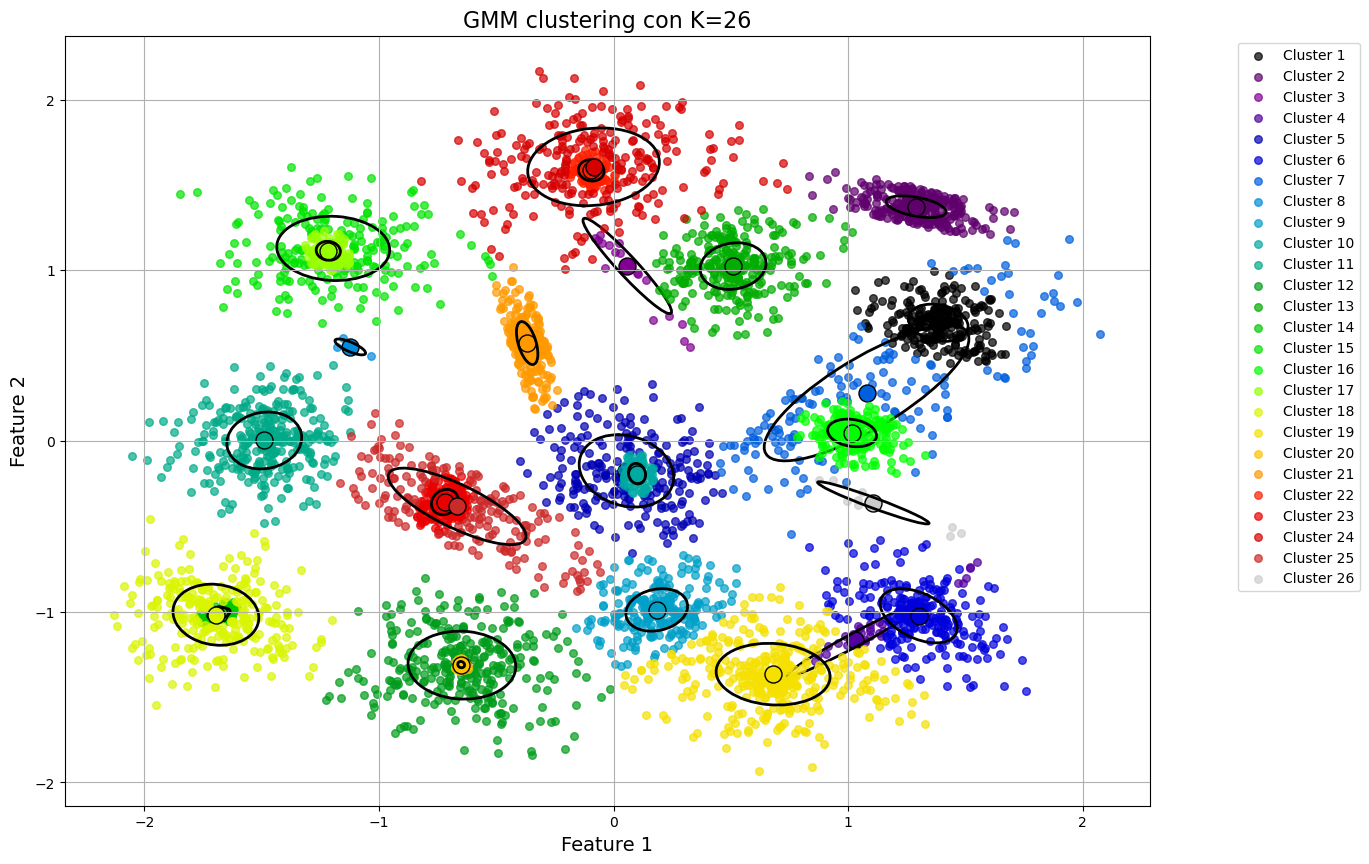

In [15]:

k_opt = best_k
model = GMM(k_opt)
l = model.fit(X)
labels = model.predict(X)
cmap = plt.cm.get_cmap("nipy_spectral", k_opt)

plt.figure(figsize=(14, 10))

for i in range(k_opt):
    cluster_points = X[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                color=cmap(i), label=f'Cluster {i+1}', s=30, alpha=0.7)

    # Centroid
    centroid = model.means[i]
    plt.scatter(centroid[0], centroid[1],
                color=cmap(i), edgecolor='black', s=150, marker='o')

    # Covariance ellipse
    cov = model.covs[i]
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # Sort eigenvalues and vectors
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # Get angle in degrees
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))

    # Width and height: 2*sqrt(eigenvalue) ~ 1 std deviation
    width, height = 2 * np.sqrt(eigenvalues)

    # Add the ellipse
    ell = Ellipse(xy=centroid, width=width, height=height, angle=angle,
                  edgecolor="black", facecolor='none', linewidth=2)
    plt.gca().add_patch(ell)

plt.title(f"GMM clustering con K={k_opt}", fontsize=16)
plt.xlabel("Feature 1", fontsize=14)
plt.ylabel("Feature 2", fontsize=14)
plt.grid(True)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0), ncol=1)
plt.show()


In [8]:
#busco params de dbscan
r_values = [0.2, 0.3, 0.4, 0.1, 0.08, 0.07, 0.09, 0.095]
min_pts_values = [ 3, 4, 5, 6, 7, 8, 9, 10]
mejores_parametros = None
mejor_loss = np.inf
resultados = []

for r in r_values:
    for min_pts in min_pts_values:
        modelo = DBSCAN(r=r, min_pts=min_pts)
        modelo.fit(X)
        loss = modelo.silhouette_loss(X)
        resultados.append((r, min_pts, loss))

        if loss < mejor_loss:
            mejor_loss = loss
            mejores_parametros = (r, min_pts)


In [9]:
print("Mejores parámetros encontrados:")
print("r =", mejores_parametros[0])
print("min_pts =", mejores_parametros[1])
print("Silhouette loss =", mejor_loss)

Mejores parámetros encontrados:
r = 0.1
min_pts = 10
Silhouette loss = -0.6099140514999182


In [16]:
model = DBSCAN(r=0.1, min_pts=10) 
model.fit(X)

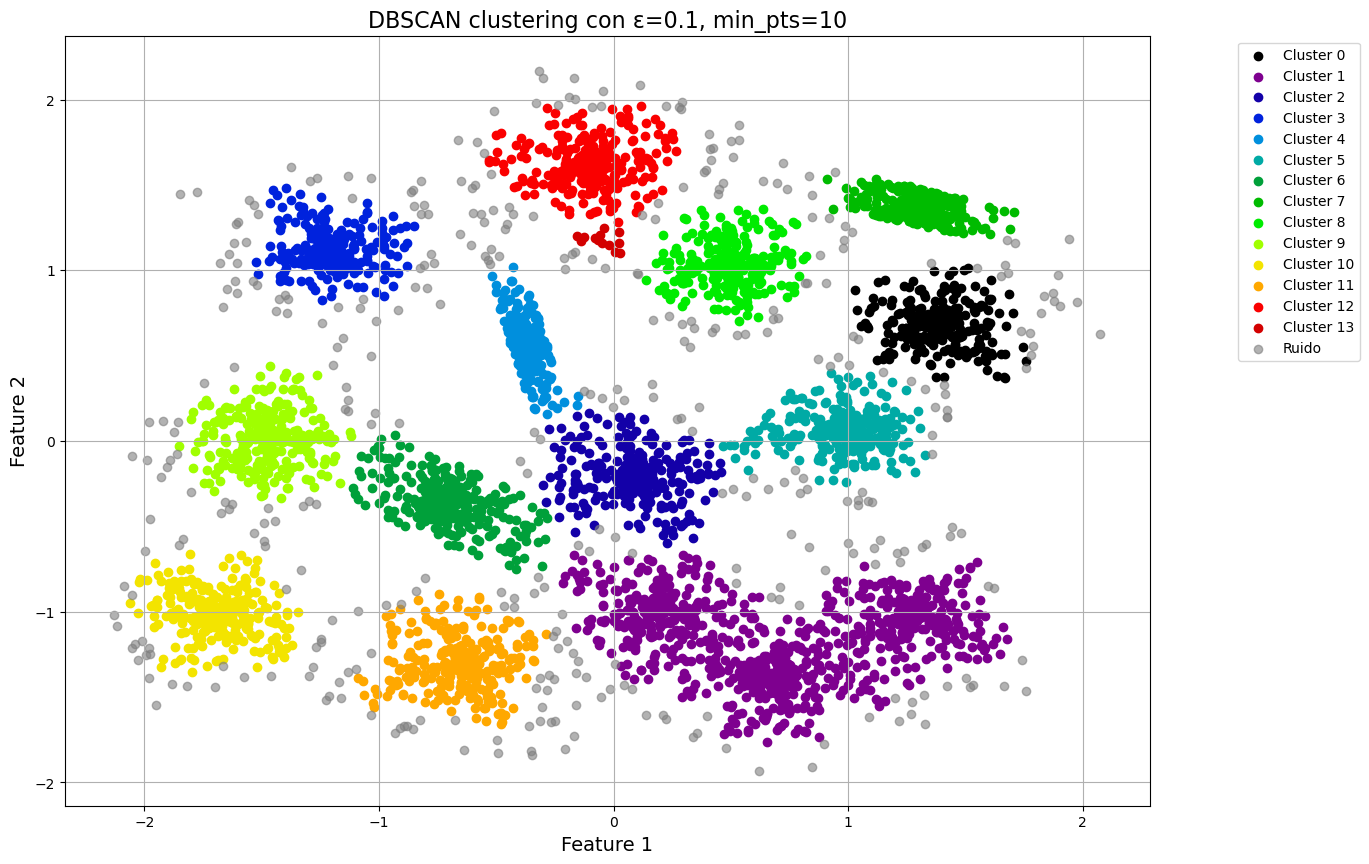

In [17]:
labels = model.get_labels()
unique_labels = set(labels)

plt.figure(figsize=(14, 10))
cmap = plt.cm.get_cmap("nipy_spectral", len(unique_labels))

for label in unique_labels:
    cluster = X[labels == label]
    if label == -1:
        # Plot noise in gray
        plt.scatter(cluster[:, 0], cluster[:, 1], color='gray', label="Ruido", alpha=0.6)
    else:
        color = cmap(label)
        plt.scatter(cluster[:, 0], cluster[:, 1], color=color, label=f"Cluster {label}")

plt.title(f"DBSCAN clustering con ε=0.1, min_pts=10", fontsize=16)
plt.xlabel("Feature 1", fontsize=14)
plt.ylabel("Feature 2", fontsize=14)
plt.grid(True)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0), ncol=1)
plt.show()

In [18]:
df = pd.read_csv("data/MNIST_dataset.csv")
labels = df.iloc[:, 0].values
df = df.iloc[:, 1:] #saco los indices
print("Shape de X_images:",df.shape)    
# revisar nans, dataset bastante limpio
print("Cantidad de nan en X_images:", np.isnan(df).sum())

X = df.values


Shape de X_images: (70000, 784)
Cantidad de nan en X_images: 1x1      0
1x2      0
1x3      0
1x4      0
1x5      0
        ..
28x24    0
28x25    0
28x26    0
28x27    0
28x28    0
Length: 784, dtype: int64


# Reducción de dimensionalidad

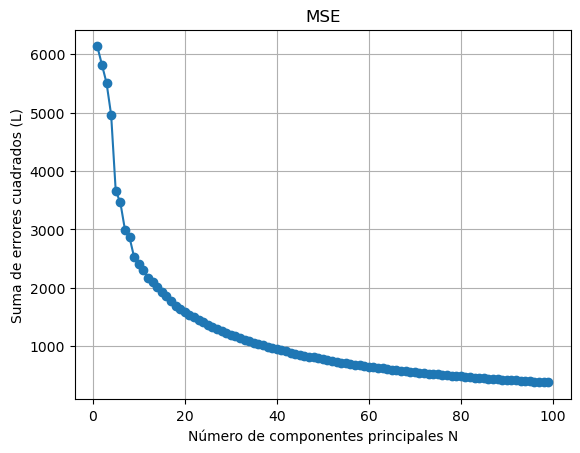

Mejor número de componentes: None


In [20]:
tol = 1e-3
best_loss = float('inf')
best_n = None
loss_n = []
wait = 0
patience = 5  

Ns = range(1, 100)
for n in Ns:
    model = PCA(n_components=n)
    model.fit(X)
    l = model.reconstruction_error(X)
    loss_n.append(l)

    # Verificar mejora, pero deberia ser siempre
    if best_loss - l > tol:
        best_loss = l
        best_k = k


plt.plot(Ns[:len(loss_n)], loss_n, marker='o')
plt.title("MSE")
plt.xlabel("Número de componentes principales N")
plt.ylabel("Suma de errores cuadrados (L)")
plt.grid(True)
plt.show()

print(f"Mejor número de componentes: {best_n}") # siepre mientras mas componentes mejor

In [21]:
model = PCA(n_components=X.shape[1]) # busco los mejores
model.fit(X)
n_components_80 = model.best_components()
print(f"Mejor número de componentes para 80% de varianza: {n_components_80}")


Mejor número de componentes para 80% de varianza: 43


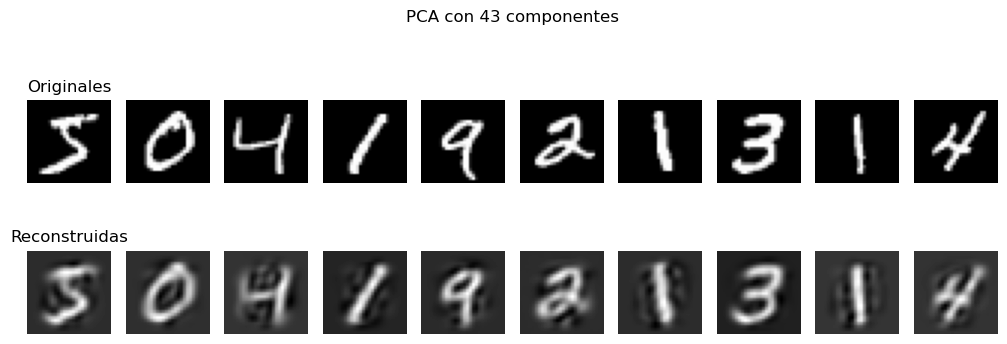

In [22]:
n = 43
pca = PCA(n_components=n)
pca.fit(X)
X_proj = pca.transform(X)
X_rec = pca.inverse_transform(X_proj)

# Mostrar originales y reconstruidas
num_images = 10
plt.figure(figsize=(10, 4))

for i in range(10):
    # Imagen original
    plt.subplot(2, num_images, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title("Originales")

    # Imagen reconstruida
    plt.subplot(2, num_images, i + 1 + num_images)
    plt.imshow(X_rec[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title("Reconstruidas")

plt.suptitle(f"PCA con {n} componentes")
plt.tight_layout()
plt.show()

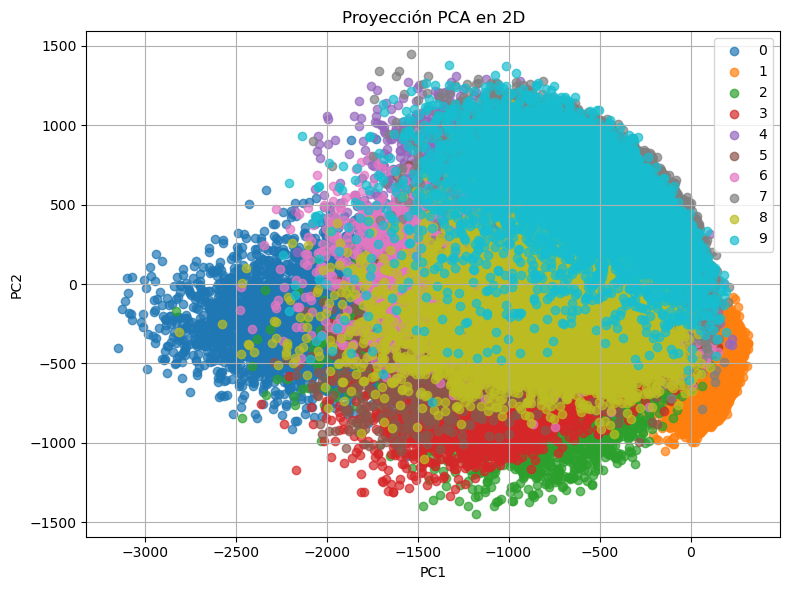

In [ ]:
#proyeccion a 2D
pca = PCA(n_components=2)
pca.fit(X)
X_pca = pca.transform(X)

plt.figure(figsize=(8, 6))
for label in np.unique(labels):
    idx = labels == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=str(label), alpha=0.7)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Proyección PCA en 2D')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:


df = pd.read_csv("data/MNIST_dataset.csv")


y = df.iloc[:, 0].values.astype(np.int64)
X = df.iloc[:, 1:].values.astype(np.float32) / 255.0


X_tensor = torch.tensor(X).view(-1, 1, 28, 28)
y_tensor = torch.tensor(y)


full_dataset = TensorDataset(X_tensor, y_tensor)


train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])


train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 43
lr = 1e-3
epochs = 20
model = VAE(latent_dim).to(device)
def loss_function(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')

    # Divergencia KL: misma fórmula que en VAE estándar
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kl_div

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
model.train()
for epoch in range(epochs):
    train_loss = 0
    for batch, _ in train_loader:
        batch = batch.to(device)
        recon_batch, mu, logvar = model(batch)
        loss = loss_function(recon_batch, batch, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f"Epoch {epoch+1}, Train Loss: {train_loss / len(train_loader.dataset):.4f}")

Epoch 1, Train Loss: 47.4316
Epoch 2, Train Loss: 36.9642
Epoch 3, Train Loss: 34.4101
Epoch 4, Train Loss: 33.0616
Epoch 5, Train Loss: 32.2667
Epoch 6, Train Loss: 31.7778
Epoch 7, Train Loss: 31.4243
Epoch 8, Train Loss: 31.1563
Epoch 9, Train Loss: 30.9070
Epoch 10, Train Loss: 30.7262
Epoch 11, Train Loss: 30.5715
Epoch 12, Train Loss: 30.4513
Epoch 13, Train Loss: 30.2895
Epoch 14, Train Loss: 30.2075
Epoch 15, Train Loss: 30.1043
Epoch 16, Train Loss: 30.0312
Epoch 17, Train Loss: 29.9378
Epoch 18, Train Loss: 29.8908
Epoch 19, Train Loss: 29.7659
Epoch 20, Train Loss: 29.7231


In [27]:
train_images = []
for batch, _ in train_loader:
    train_images.append(batch)
train_images = torch.cat(train_images, dim=0)
train_images_np = train_images.view(len(train_images), -1).numpy()
# ajusto el df para el input de PCA
pca = PCA(n_components=43) 
pca.fit(train_images_np)

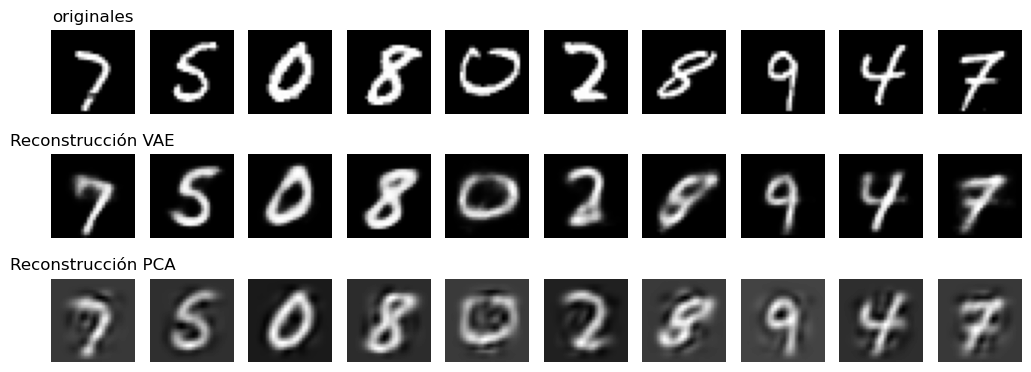

In [ ]:

model.eval()
images,_ = next(iter(val_loader))
images = images[:10].to(device)

# Reconstrucción con VAE
with torch.no_grad():
    recon_vae, _, _ = model(images)


images_np = images.view(10, -1).cpu().numpy()


X_proj = pca.transform(images_np)
X_rec_pca = pca.inverse_transform(X_proj)

def show_images(original, recon_vae, recon_pca, n=10):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        # Original
        plt.subplot(3, n, i + 1)
        plt.imshow(original[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.title("originales")
        if i == 0: plt.ylabel("Original", fontsize=10)

        # VAE
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(recon_vae[i].cpu().squeeze().numpy(), cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.title("Reconstrucción VAE")
        if i == 0: plt.ylabel("VAE", fontsize=10)

        # PCA
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(X_rec_pca[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.title("Reconstrucción PCA")
        if i == 0: plt.ylabel("PCA", fontsize=10)
    
    plt.tight_layout()
    plt.show()


show_images(images_np, recon_vae, X_rec_pca)

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 2
lr = 1e-3
epochs = 20
model2d = VAE(latent_dim).to(device)


optimizer = torch.optim.Adam(model2d.parameters(), lr=lr)
model2d.train()
for epoch in range(epochs):
    train_loss = 0
    for batch, _ in train_loader:
        batch = batch.to(device)
        recon_batch, mu, logvar = model2d(batch)
        loss = loss_function(recon_batch, batch, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f"Epoch {epoch+1}, Train Loss: {train_loss / len(train_loader.dataset):.4f}")

Epoch 1, Train Loss: 49.7025
Epoch 2, Train Loss: 42.5017
Epoch 3, Train Loss: 41.2450
Epoch 4, Train Loss: 40.4723
Epoch 5, Train Loss: 39.9090
Epoch 6, Train Loss: 39.4710
Epoch 7, Train Loss: 39.0931
Epoch 8, Train Loss: 38.8005
Epoch 9, Train Loss: 38.5492
Epoch 10, Train Loss: 38.3127
Epoch 11, Train Loss: 38.1331
Epoch 12, Train Loss: 37.9689
Epoch 13, Train Loss: 37.8355
Epoch 14, Train Loss: 37.6874
Epoch 15, Train Loss: 37.5630
Epoch 16, Train Loss: 37.4738
Epoch 17, Train Loss: 37.3553
Epoch 18, Train Loss: 37.2585
Epoch 19, Train Loss: 37.1536
Epoch 20, Train Loss: 37.0844


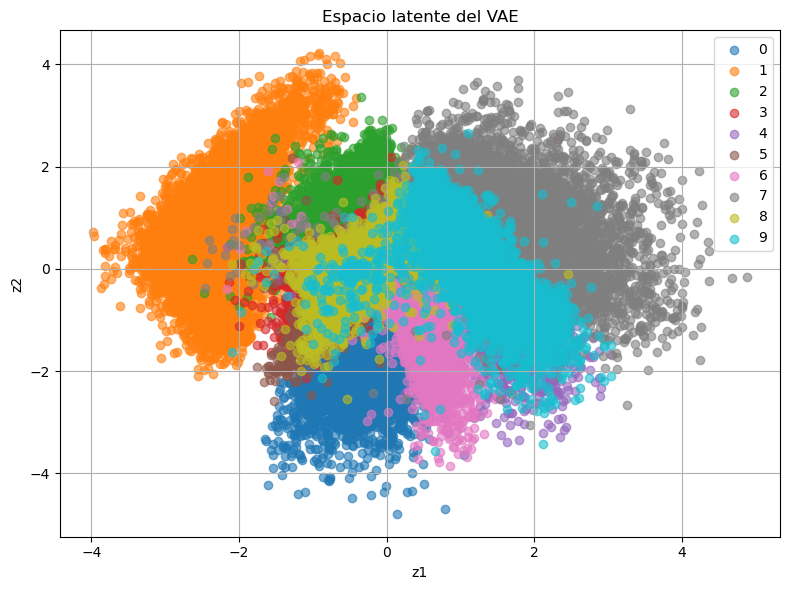

In [ ]:
model2d.eval()

all_z = []
all_labels = []

with torch.no_grad():
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        mu, logvar = model2d.encoder(x_batch)
        z = model2d.reparameterize(mu, logvar)
        all_z.append(z.cpu())
        all_labels.append(y_batch.cpu())

z_all = torch.cat(all_z).numpy()
labels_all = torch.cat(all_labels).numpy()


plt.figure(figsize=(8, 6))
for label in np.unique(labels_all):
    idx = labels_all == label
    plt.scatter(z_all[idx, 0], z_all[idx, 1], label=str(label), alpha=0.6)

plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Espacio latente del VAE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

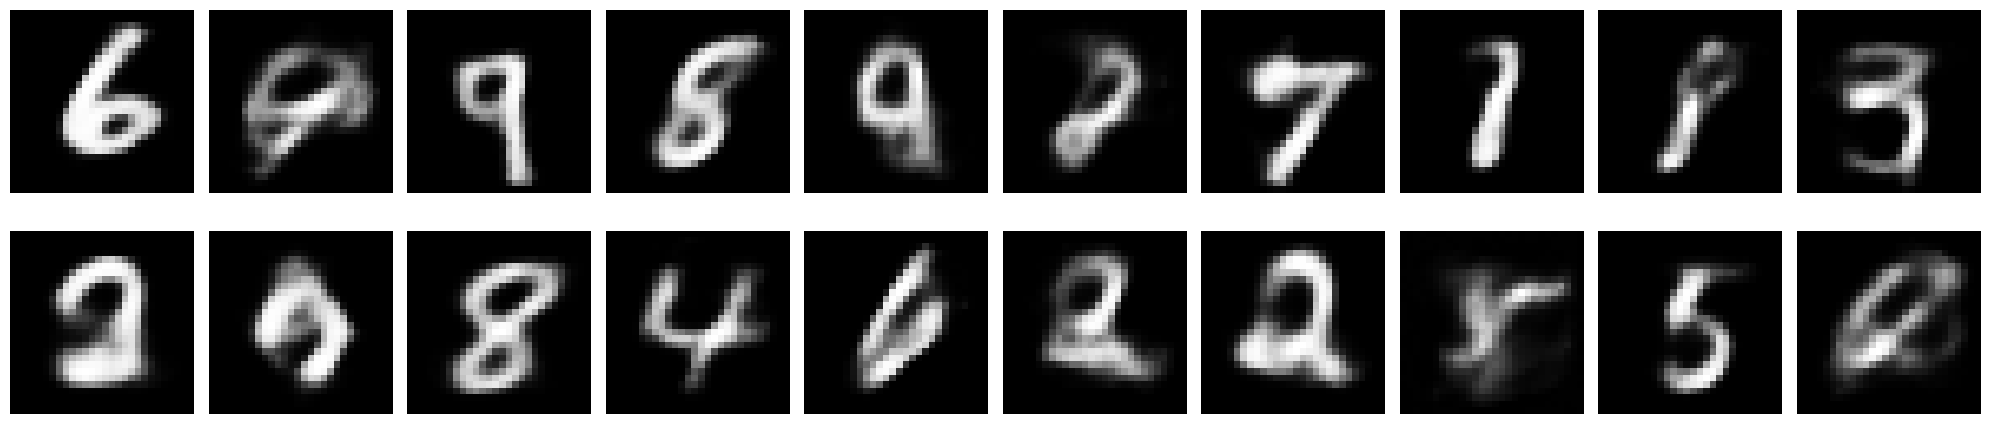

In [ ]:

model.eval()


num_samples = 20
latent_dim = 43


z = torch.randn(num_samples, latent_dim)


with torch.no_grad():
    generated_samples = model.decoder(z)

rows = 2
cols = 10
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.5))

for i in range(num_samples):
    r = i // cols
    c = i % cols
    axes[r, c].imshow(generated_samples[i].squeeze().cpu().numpy(), cmap='gray')
    axes[r, c].axis('off')

# Si sobran subplots, ocultarlos
for i in range(num_samples, rows * cols):
    r = i // cols
    c = i % cols
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()
